# Sazonalidade dos cetáceos em Portugal

**Pergunta:** que espécies de cetáceos são observadas em que meses, e isso muda entre os Açores,
a Madeira e o Continente?

**Dados:** GBIF.org (7 October 2026) GBIF Occurrence Download https://doi.org/10.15468/dl.mzf9rc

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import folium
from folium.plugins import HeatMapWithTime

## 1. Carregar os dados

In [2]:
dados = pd.read_csv("DADOS GBIF.csv", sep="\t", low_memory=False)
print(len(dados), "observações no ficheiro")

188687 observações no ficheiro


In [3]:
colunas = ["species", "eventDate", "year", "month",
           "decimalLatitude", "decimalLongitude", "stateProvince"]
dados = dados.reindex(columns=colunas)

dados.head(10)

,species,eventDate,year,month,decimalLatitude,decimalLongitude,stateProvince
0,Physeter macrocephalus,NaN,NaN,NaN,37.500000,-25.500000,NaN
1,Balaenoptera musculus,1998/2012,NaN,NaN,37.076666,-25.257876,NaN
2,Stenella frontalis,2007/2012,NaN,NaN,39.433666,-27.463073,NaN
3,Delphinus delphis,2007/2012,NaN,NaN,39.067236,-10.083241,NaN
4,Globicephala macrorhynchus,2007/2012,NaN,NaN,37.044987,-29.095874,NaN
5,Stenella frontalis,2007/2012,NaN,NaN,37.343615,-26.303139,NaN
6,Delphinus delphis,2007/2012,NaN,NaN,37.908427,-26.121951,NaN
7,Stenella frontalis,2007/2012,NaN,NaN,38.597744,-30.537244,NaN
8,Delphinus delphis,2007/2012,NaN,NaN,38.614267,-9.587039,NaN
9,Physeter macrocephalus,1998/2012,NaN,NaN,39.582571,-29.456363,NaN


## 2. Limpeza e regiões

In [4]:
# 1. De que anos são as observações?
print(dados["year"].value_counts().sort_index())

# 2. Remover observações sem espécie identificada ou sem mês
dados = dados.dropna(subset=["species", "month"])
dados["month"] = dados["month"].astype(int)

# 3. Criar a coluna "regiao" a partir das coordenadas
def definir_regiao(linha):
    if linha["decimalLongitude"] < -24:
        return "Açores"
    elif linha["decimalLatitude"] < 34:
        return "Madeira"
    else:
        return "Continente"

dados["regiao"] = dados.apply(definir_regiao, axis=1)

# 4. Quantas observações por região?
print(dados["regiao"].value_counts())

year
1526.0       1
1723.0       1
1782.0       1
1784.0       1
1843.0       1
          ... 
2022.0    1203
2023.0    1886
2024.0    3244
2025.0    1601
2026.0    1071
Name: count, Length: 92, dtype: int64


regiao
Açores        136261
Madeira         5870
Continente      4629
Name: count, dtype: int64


## 3. Nomes comuns das espécies

In [5]:
nomes_comuns = {
    "Physeter macrocephalus": "Cachalote",
    "Balaenoptera musculus": "Baleia-azul",
    "Balaenoptera physalus": "Baleia-comum",
    "Balaenoptera borealis": "Baleia-sardinheira",
    "Balaenoptera acutorostrata": "Baleia-anã",
    "Megaptera novaeangliae": "Baleia-de-bossa",
    "Delphinus delphis": "Golfinho-comum",
    "Tursiops truncatus": "Roaz",
    "Stenella coeruleoalba": "Golfinho-riscado",
    "Stenella frontalis": "Golfinho-pintado-do-atlântico",
    "Grampus griseus": "Grampo",
    "Orcinus orca": "Orca",
    "Pseudorca crassidens": "Falsa-orca",
    "Globicephala macrorhynchus": "Baleia-piloto-tropical",
    "Globicephala melas": "Baleia-piloto",
    "Steno bredanensis": "Caldeirão",
    "Ziphius cavirostris": "Baleia-de-bico-de-Cuvier",
    "Phocoena phocoena": "Boto",
    "Balaenoptera edeni": "Baleia-de-Bryde",
}

def rotulo(nome_cientifico):
    comum = nomes_comuns.get(nome_cientifico, "")
    if comum:
        return f"{comum} ({nome_cientifico})"
    return nome_cientifico

## 4. Período de estudo

Número de observações por ano, para escolher o período a analisar.

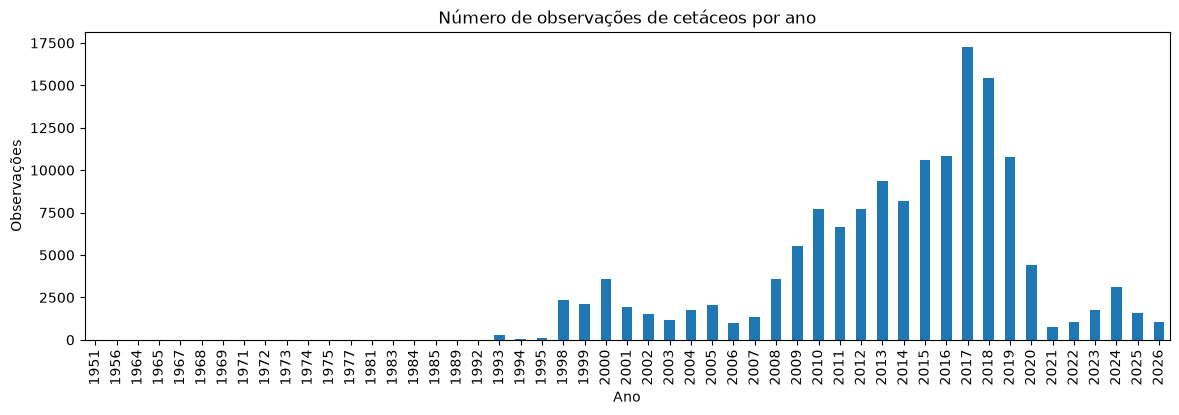

In [6]:
obs_por_ano = dados["year"].value_counts().sort_index()
obs_por_ano = obs_por_ano[obs_por_ano.index >= 1950]
obs_por_ano.index = obs_por_ano.index.astype(int)
obs_por_ano.plot(kind="bar", figsize=(14, 4))
plt.title("Número de observações de cetáceos por ano")
plt.xlabel("Ano")
plt.ylabel("Observações")
plt.show()

In [7]:
# Período de estudo: de 2000 até à atualidade
dados["year"] = pd.to_numeric(dados["year"], errors="coerce")
dados_estudo = dados[dados["year"] >= 2000]

print("Observações no período:", len(dados_estudo))
print("Anos:", int(dados_estudo["year"].min()), "a", int(dados_estudo["year"].max()))
print(dados_estudo["regiao"].value_counts())

Observações no período: 141754
Anos: 2000 a 2026
regiao
Açores        131437
Madeira         5866
Continente      4451
Name: count, dtype: int64


## 5. Sazonalidade por região

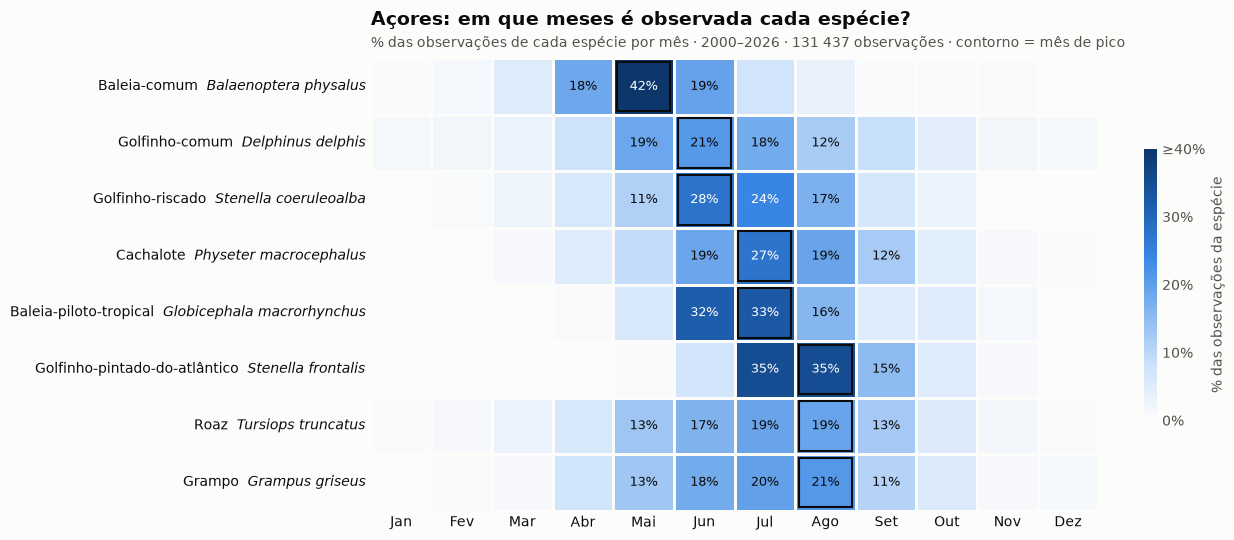

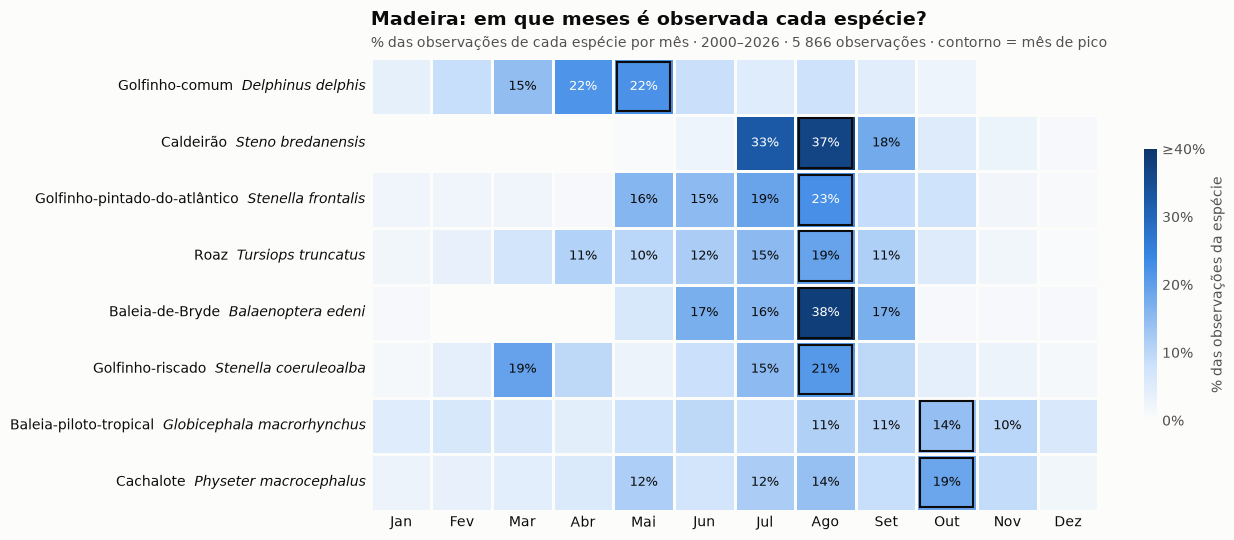

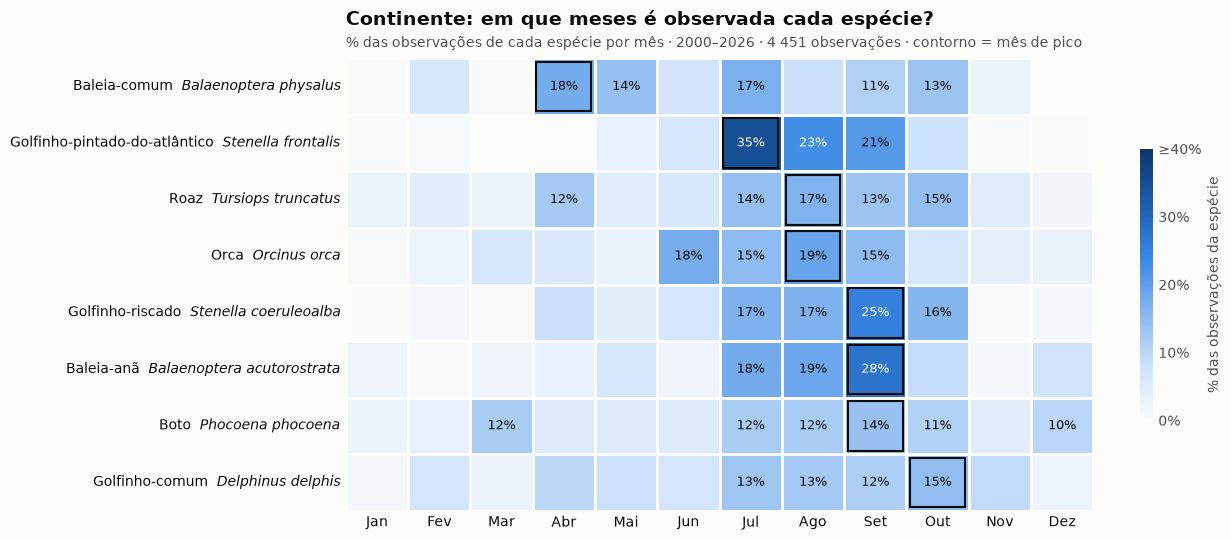

In [8]:
# Heatmaps de sazonalidade por região (2000–atualidade)
os.makedirs("figuras", exist_ok=True)  # pasta para guardar as imagens

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Cores: um só tom de azul, do quase-branco (0%) ao azul-escuro (máximo)
FUNDO = "#fcfcfb"
TEXTO = "#0b0b0b"
TEXTO_SECUNDARIO = "#52514e"
azuis = LinearSegmentedColormap.from_list(
    "azuis", [FUNDO, "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

def rotulo_eixo(nome_cientifico):
    # Nome comum + nome científico em itálico (convenção da biologia)
    comum = nomes_comuns.get(nome_cientifico, "")
    italico = "$\\it{" + nome_cientifico.replace(" ", "\\ ") + "}$"
    if comum:
        return f"{comum}  {italico}"
    return italico

def heatmap_regiao(regiao, n_especies=8):
    dados_regiao = dados_estudo[dados_estudo["regiao"] == regiao]

    principais = dados_regiao["species"].value_counts().head(n_especies).index
    dados_top = dados_regiao[dados_regiao["species"].isin(principais)]

    tabela = pd.crosstab(dados_top["species"], dados_top["month"])
    tabela = tabela.reindex(index=principais, columns=range(1, 13), fill_value=0)
    tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

    # Ordenar as espécies pelo mês de pico: o padrão sazonal lê-se de cima para baixo
    pico = tabela_pct.idxmax(axis=1)
    tabela_pct = tabela_pct.loc[pico.sort_values(kind="stable").index]

    # Só escrever os valores >= 10% (os outros ficam só com a cor)
    anotacoes = tabela_pct.round(0).astype(int).astype(str) + "%"
    anotacoes = anotacoes.where(tabela_pct >= 10, "")

    fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=FUNDO)
    sns.heatmap(
        tabela_pct, ax=ax, cmap=azuis, vmin=0, vmax=40,
        annot=anotacoes, fmt="", annot_kws={"fontsize": 9},
        linewidths=2, linecolor=FUNDO,           # espaço entre as células
        cbar_kws={"label": "% das observações da espécie", "shrink": 0.6, "ticks": [0, 10, 20, 30, 40]},
        xticklabels=meses,
        yticklabels=[rotulo_eixo(n) for n in tabela_pct.index],
    )

    # Texto escuro em células claras, branco em células escuras
    for texto in ax.texts:
        if texto.get_text():
            valor = int(texto.get_text().rstrip("%"))
            texto.set_color("white" if valor >= 22 else TEXTO)

    # Destacar o mês de pico de cada espécie com um contorno
    for linha, especie in enumerate(tabela_pct.index):
        coluna = tabela_pct.columns.get_loc(tabela_pct.loc[especie].idxmax())
        ax.add_patch(plt.Rectangle((coluna + 0.06, linha + 0.06), 0.88, 0.88,
                                   fill=False, edgecolor=TEXTO, linewidth=1.5))

    # Títulos e eixos discretos
    ax.set_title(f"{regiao}: em que meses é observada cada espécie?",
                 loc="left", fontsize=14, fontweight="bold", color=TEXTO, pad=24)
    ax.text(0, 1.025, f"% das observações de cada espécie por mês · 2000–2026 · "
            f"{len(dados_regiao):,} observações · contorno = mês de pico".replace(",", " "),
            transform=ax.transAxes, fontsize=10, color=TEXTO_SECUNDARIO)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(length=0, colors=TEXTO, labelsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0)
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(length=0, colors=TEXTO_SECUNDARIO)
    cbar.ax.yaxis.label.set_color(TEXTO_SECUNDARIO)
    cbar.ax.set_yticklabels(["0%", "10%", "20%", "30%", "≥40%"])

    plt.tight_layout()

    # Guardar a imagem (para o README) e mostrar
    nome_ficheiro = regiao.lower().replace("ç", "c")
    plt.savefig(f"figuras/heatmap_{nome_ficheiro}.png", dpi=150, facecolor=FUNDO)
    plt.show()

for regiao in ["Açores", "Madeira", "Continente"]:
    heatmap_regiao(regiao)


### Interpretação

**Açores (n = 131 437).** A maioria das espécies tem o pico de observações entre junho e agosto.
A exceção é a baleia-comum, com pico em maio (42% das observações), o que é consistente com a
passagem pelo arquipélago durante a migração de primavera. O golfinho-pintado-do-atlântico é a
espécie mais sazonal: 70% das observações concentram-se em julho e agosto.

**Madeira (n = 5 866).** A baleia-piloto-tropical é observada ao longo de todo o ano, o que sugere
a presença de uma população residente. A baleia-de-Bryde e o caldeirão concentram-se no final do
verão, e o golfinho-comum tem o pico na primavera (março a maio), ao contrário do que acontece nos Açores.

**Continente (n = 4 451).** Os padrões são menos marcados e várias espécies continuam a ser
observadas até setembro e outubro. O boto é das espécies mais regulares ao longo do ano.

**Limitações:**
- Os dados não medem a abundância real, só onde e quando houve observadores. No verão há mais
  barcos de observação de baleias, por isso é natural haver mais registos.
- 93% das observações são dos Açores; os resultados da Madeira e do Continente baseiam-se em
  muito menos dados.
- Há poucos registos em 2020 (pandemia) e de 2021 em diante (dados provavelmente ainda por publicar no GBIF).

## 6. Mapa sazonal das observações

In [9]:
# Agrupar observações próximas (coordenadas arredondadas a ~1 km)
# para o mapa não ficar demasiado pesado
pontos = dados_estudo.copy()
pontos["lat"] = pontos["decimalLatitude"].round(2)
pontos["lon"] = pontos["decimalLongitude"].round(2)
contagens = pontos.groupby(["month", "lat", "lon"]).size().reset_index(name="n")

# Uma lista de pontos [lat, lon, número de observações] para cada mês
dados_por_mes = []
for mes in range(1, 13):
    deste_mes = contagens[contagens["month"] == mes]
    dados_por_mes.append(deste_mes[["lat", "lon", "n"]].values.tolist())

# Criar o mapa centrado entre o Continente e os Açores
mapa = folium.Map(location=[38.5, -17], zoom_start=5)

HeatMapWithTime(
    dados_por_mes,
    index=meses,          # nomes dos meses na barra (Jan, Fev, ...)
    radius=8,
    auto_play=False,
    max_opacity=0.8,
).add_to(mapa)

# Guardar como página web (para o GitHub)
mapa.save("mapa_sazonal.html")

O mapa interativo [`mapa_sazonal.html`](mapa_sazonal.html) mostra a densidade de observações
em cada mês (2000–2026). Os Açores concentram a grande maioria dos registos, com um aumento
muito marcado entre maio e setembro e quase nenhuma observação no inverno. Este padrão reflete
tanto a presença sazonal das espécies como o aumento da atividade de observação de baleias no verão.

*Nota: no VS Code o mapa não aparece dentro do notebook; abrir o ficheiro HTML no browser.*